# DDH Complete Diagnosis System
**Unified Notebook** — Classification + Keypoint Detection + Severity + Medical Guidance

**Datasets used:**
- [MTDDH Pelvic X-Ray — Severity via Keypoints (Mild / Moderate / Severe)](https://www.kaggle.com/datasets/amirmmahdavikia/mtddh-pelvic-x-ray)
- [Mendeley DDH Dataset — Multi Classification (DDH / Normal / Not_X-ray)](https://data.mendeley.com/datasets/jf3pv98m9g/2)

## Mount Google Drive to access files


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# This will ask for authorization to link your Google Drive

Mounted at /content/drive


# 1. Install Libraries


In [ ]:
# Install required libraries for the project
# (deep learning, data processing, visualization, and image handling)
#!pip install torch torchvision scikit-learn matplotlib seaborn opencv-python Pillow tqdm --quiet


# 2. Import Libraries


In [ ]:
# Import Required Libraries for DDH Project

# General-purpose libraries
import os, json, math, copy, re
# Used for file handling, reading JSON data, math operations,
# copying objects, and text processing

import numpy as np
# Used for numerical operations and array manipulation

import cv2
# OpenCV library for image processing (enhancement, filtering, etc.)

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
# Used for plotting images, graphs, and customizing layouts

import seaborn as sns
# Used for advanced statistical visualizations (e.g., confusion matrix)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')
# Helps keep notebook output clean and easy to read

# PyTorch Libraries (Deep Learning Framework)

import torch
# Core PyTorch library

import torch.nn as nn
# Used to build neural network layers

import torch.nn.functional as F
# Provides activation functions and other utilities

import torch.optim as optim
# Contains optimization algorithms (e.g., Adam, AdamW)

# Data handling utilities
from torch.utils.data import DataLoader, Dataset, ConcatDataset, Subset, WeightedRandomSampler
# Used to load data, create custom datasets,
# combine datasets, and handle class imbalance

from torchvision import datasets, transforms, models
# Provides image datasets, preprocessing transforms,
# and pretrained models like DenseNet

from collections import defaultdict, Counter
# Useful for counting and organizing dataset labels

# Evaluation & Data Splitting

from sklearn.metrics import classification_report, confusion_matrix
# Used to evaluate model performance:
# - Precision
# - Recall
# - F1-score
# - Confusion matrix

from sklearn.model_selection import train_test_split
# Used to split dataset into training and validation sets

from tqdm.auto import tqdm
# Displays progress bars during training for better monitoring

# Image Handling

from PIL import Image, ImageFile
# Used for opening and processing images

ImageFile.LOAD_TRUNCATED_IMAGES = True
# Allows loading corrupted or incomplete images without crashing

# Confirmation Message

print('✅ Libraries imported successfully.')
# Confirms that all required libraries are loaded correctly


✅ Libraries imported successfully.


# 3. Device Setup


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Check if GPU (CUDA) is available
# If yes → use GPU for faster training
# If not → fall back to CPU

print(f'Using device: {device}')
# Print which device is being used (CPU or GPU)

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    # If GPU exists, print the GPU name for confirmation

Using device: cuda
GPU: Tesla T4


# 4. Constants (Keypoint Names, Colors, Dataset2 Mapping)


In [ ]:
# Keypoints Configuration for DDH Detection

# Define keypoint names (anatomical landmarks)
KEYPOINT_NAMES = [
    'RTCC',   # Right Triradiate Cartilage Center
    'LTCC',   # Left  Triradiate Cartilage Center
    'RASM',   # Right Acetabular Superior Margin
    'LASM',   # Left  Acetabular Superior Margin
    'RFHC',   # Right Femoral Head Center
    'LFHC',   # Left  Femoral Head Center
    'RMOFM',  # Right Medial Ossification Front Margin
    'LMOFM',  # Left  Medial Ossification Front Margin
]
# These are the 8 anatomical points used for DDH analysis

NUM_KP = len(KEYPOINT_NAMES)
# Total number of keypoints (8)

INPUT_SIZE = 512
# Input image size used for the model (512x512)

HEATMAP_SIZE = 64
# Output heatmap size (downsampled from input for efficiency)

SIGMA = 3
# Standard deviation for Gaussian heatmap generation (controls spread of keypoint)

# Colors used for visualizing each keypoint
KEYPOINT_COLORS = [
    '#e6194b','#3cb44b','#4363d8','#f58231',
    '#911eb4','#42d4f4','#f032e6','#bfef45'
]
# Each keypoint will have a unique color when plotted

# Dataset2 Keypoint Mapping (IMPORTANT)

# In Dataset2, annotations are given as:
# ['A', 'B', 'C', 'H'] for each side (right OR left)

# Anatomical meaning of each label:
# A → TCC  (Triradiate Cartilage Center)
# B → ASM  (Acetabular Superior Margin)
# C → FHC  (Femoral Head Center)
# H → MOFM (Medial Ossification Front Margin)

# Problem:
# Dataset does NOT directly specify left/right side

# Solution:
# Determine side using x-coordinate of point A (TCC)

# Rule:
# If A.x > image_width / 2  → RIGHT side
# If A.x ≤ image_width / 2 → LEFT side

# Mapping for RIGHT side keypoints
DS2_RIGHT_MAP = {
    'A': 0,  # RTCC
    'B': 2,  # RASM
    'C': 4,  # RFHC
    'H': 6   # RMOFM
}

# Mapping for LEFT side keypoints
DS2_LEFT_MAP = {
    'A': 1,  # LTCC
    'B': 3,  # LASM
    'C': 5,  # LFHC
    'H': 7   # LMOFM
}

# Order of keypoints in Dataset2 JSON
DS2_KP_NAMES = ['A', 'B', 'C', 'H']

# Category ID that contains keypoints in Dataset2
DS2_CAT_ID = 6
# Only this category includes keypoint annotations

# Summary Print
print(f'✅ {NUM_KP} keypoints | Input {INPUT_SIZE}px | Heatmap {HEATMAP_SIZE}px')
# Confirms configuration settings

✅ 8 keypoints | Input 512px | Heatmap 64px


# 5. CLAHE Helper, Gaussian Heatmap & Display Helper


In [ ]:
# Image Enhancement using CLAHE
class ApplyCLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8,8)):
        self.clip_limit     = clip_limit
        self.tile_grid_size = tile_grid_size
        # Initialize CLAHE parameters:
        # clip_limit controls contrast enhancement strength
        # tile_grid_size defines grid size for local equalization

    def __call__(self, img):
        arr = np.array(img)
        # Convert PIL image to NumPy array

        if arr.ndim == 3 and arr.shape[2] == 3:
            # If image is RGB

            lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)
            # Convert RGB to LAB color space (better for contrast enhancement)

            l, a, b = cv2.split(lab)
            # Split channels

            cl = cv2.createCLAHE(self.clip_limit, self.tile_grid_size).apply(l)
            # Apply CLAHE on L channel (brightness only)

            final = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2RGB)
            # Merge channels back and convert to RGB

        else:
            # If image is grayscale
            final = cv2.createCLAHE(self.clip_limit, self.tile_grid_size).apply(arr)
            # Apply CLAHE directly

        return Image.fromarray(final)
        # Convert back to PIL image


# Heatmap Generation for Keypoints
def make_heatmap(H, W, cx, cy, sigma=SIGMA):
    # Create coordinate grid
    xs = np.arange(W)
    ys = np.arange(H)
    xx, yy = np.meshgrid(xs, ys)

    # Generate Gaussian heatmap centered at (cx, cy)
    hm = np.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * sigma**2))

    return hm.astype(np.float32)
    # Return heatmap as float32 array


# Normalization Parameters (ImageNet)
_MEAN = np.array([0.485, 0.456, 0.406])
_STD  = np.array([0.229, 0.224, 0.225])
# Standard normalization values used for pretrained models


# Convert Tensor to Displayable Image
def to_display(t):
    img = t.permute(1, 2, 0).cpu().numpy()
    # Convert tensor (C,H,W) → (H,W,C)

    return np.clip(img * _STD + _MEAN, 0, 1)
    # Reverse normalization and clip values to valid range


# Confirmation Message
print('✅ Helpers ready.')
# Confirms helper functions are ready to use

✅ Helpers ready.


# 6. Classification Dataset Helper Classes


In [ ]:
# Dataset wrapper that applies transforms lazily
class DatasetWithTransform(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform
        # Store original dataset and optional transform

    def __len__(self):
        return len(self.dataset)
        # Return total number of samples in dataset

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        # Get image and label from dataset by index

        if self.transform:
            img = self.transform(img)
            # Apply transform only when loading the image (lazy processing)

        return img, label
        # Return processed image and its label


# CLAHE preprocessing (Contrast-Limited Adaptive Histogram Equalization)
# Improves X-ray image contrast and visibility

class ApplyCLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size
        # Parameters that control contrast enhancement strength

    def __call__(self, img):
        img_np = np.array(img)
        # Convert image to numpy array for OpenCV processing

        if len(img_np.shape) == 3 and img_np.shape[2] == 3:
            # If image is RGB (3 channels)

            lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            # Convert image from RGB to LAB color space

            l, a, b = cv2.split(lab)
            # Split into L (lightness), A, B channels

            clahe = cv2.createCLAHE(
                clipLimit=self.clip_limit,
                tileGridSize=self.tile_grid_size
            )
            # Create CLAHE object for contrast enhancement

            cl = clahe.apply(l)
            # Apply CLAHE only on lightness channel

            limg = cv2.merge((cl, a, b))
            # Merge channels back

            final = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
            # Convert back to RGB format

        else:
            # If grayscale image
            clahe = cv2.createCLAHE(
                clipLimit=self.clip_limit,
                tileGridSize=self.tile_grid_size
            )
            final = clahe.apply(img_np)
            # Apply CLAHE directly

        return Image.fromarray(final)
        # Convert back to PIL image format


# Clean corrupted images from dataset

def clean_dataset(dataset):
    clean_samples = []
    # List to store valid images only

    for path, label in dataset.samples:
        try:
            Image.open(path).convert('RGB')
            # Try opening image to check if it's valid

            clean_samples.append((path, label))
            # Keep valid image

        except Exception:
            print(f' Removed corrupted: {path}')
            # Skip corrupted image and show warning

    dataset.samples = clean_samples
    # Replace dataset with cleaned version

    return dataset
    # Return cleaned dataset


print('✅ Helper classes ready.')
# Confirmation message that preprocessing tools are ready

✅ Helper classes ready.


# 7. Image Transforms



In [ ]:
# Classification Transforms (224×224)
clf_train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    # Resize image to match classifier input size

    transforms.Lambda(lambda img: img.convert('RGB')),
    # Ensure image is in RGB format

    ApplyCLAHE(clip_limit=2.0, tile_grid_size=(8, 8)),
    # Enhance contrast (important for X-ray clarity)

    transforms.RandomHorizontalFlip(),
    # Random flip for data augmentation (improves generalization)

    transforms.RandomRotation(15),
    # Random rotation to simulate different orientations

    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    # Slight brightness and contrast variation

    transforms.ToTensor(),
    # Convert image to PyTorch tensor

    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
    # Normalize using ImageNet statistics
])

# Validation / Test transforms (no augmentation)
clf_val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    # Same resize as training

    transforms.Lambda(lambda img: img.convert('RGB')),
    # Ensure RGB format

    ApplyCLAHE(clip_limit=2.0, tile_grid_size=(8, 8)),
    # Apply same enhancement (avoid data mismatch)

    transforms.ToTensor(),

    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
    # Normalize input
])

# Keypoint Detection Transforms (512×512)
kp_train_tfm = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    # Resize to higher resolution (better for localization)

    transforms.Lambda(lambda i: i.convert('RGB')),
    # Ensure RGB format

    ApplyCLAHE(2.0, (8, 8)),
    # Improve visibility of anatomical landmarks

    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    # Light augmentation for robustness

    transforms.ToTensor(),

    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Validation transforms for keypoints (no augmentation)
kp_val_tfm = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),

    transforms.Lambda(lambda i: i.convert('RGB')),

    ApplyCLAHE(2.0, (8, 8)),

    transforms.ToTensor(),

    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Aliases for Easy Usage in Code
val_tfm = kp_val_tfm
# Used for keypoint inference

val_test_transforms = clf_val_transforms
# Used for classifier inference

train_tfm = kp_train_tfm
# Used for keypoint training


# Confirmation Message
print('✅ Transforms ready (clf=224px | keypoint=512px).')
# Confirms transforms are configured correctly

✅ Transforms ready (clf=224px | keypoint=512px).


# 8. Model Definitions
## 8-A. DenseNet-121 Classifier (Jordan DDH)


In [ ]:
def build_densenet(num_classes):
    """
    DenseNet-121 pretrained on ImageNet.
    - Freeze most layers to keep learned features.
    - Fine-tune only last part of the network.
    - Add custom classifier for our dataset.
    """

    model = models.densenet121(weights='IMAGENET1K_V1')
    # Load pretrained DenseNet-121 model trained on ImageNet

    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False
        # Freeze all layers so they are not updated during training

    #  Unfreeze last layers
    for param in model.features.denseblock4.parameters():
        param.requires_grad = True
        # Unfreeze last dense block for fine-tuning

    for param in model.features.norm5.parameters():
        param.requires_grad = True
        # Unfreeze final normalization layer

    # Get number of input features for classifier (1024 for DenseNet-121)
    num_ftrs = model.classifier.in_features

    #  Custom classifier head
    model.classifier = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        # Reduce features from 1024 → 512

        nn.BatchNorm1d(512),
        # Normalize for stable training

        nn.ReLU(),
        # Activation function

        nn.Dropout(0.5),
        # Dropout to reduce overfitting

        nn.Linear(512, 256),
        # Further reduce features

        nn.BatchNorm1d(256),
        # Normalize again

        nn.ReLU(),
        # Activation function

        nn.Dropout(0.4),
        # Another dropout layer

        nn.Linear(256, num_classes)
        # Final output layer (number of classes)
    )

    return model.to(device)
    # Move model to GPU if available


print('✅ build_densenet() ready.')
# Confirmation message that model builder is ready

✅ build_densenet() ready.


## 8-B. DDH Keypoint Network (DenseNet-121 Encoder + Heatmap Decoder)


In [ ]:
# Upsampling Block (Decoder Part)
class UpBlock(nn.Module):
    """
    Upsampling block used in decoder.
    Performs:
    Transposed Convolution → BatchNorm → ReLU

    Purpose:
    Increase spatial resolution (×2) for feature maps.
    """

    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.b = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1),
            # Transposed convolution (upsampling by factor of 2)

            nn.BatchNorm2d(out_ch),
            # Normalize feature maps for stable training

            nn.ReLU(inplace=True)
            # Activation function to add non-linearity
        )

    def forward(self, x):
        return self.b(x)
        # Pass input through upsampling block


# Confirmation Message
print('✅ UpBlock ready.')

✅ UpBlock ready.


In [ ]:
# DDH Keypoint Detection Model
class DDHKeypointNet(nn.Module):
    """
    Model for detecting anatomical keypoints in hip X-ray images.

    Architecture:
    - Encoder: DenseNet-121 (pretrained on ImageNet)
    - Decoder: Lightweight upsampling network (heatmap prediction)

    Input : (B, 3, 512, 512)
    Output: (B, NUM_KP, 64, 64)
    """

    def __init__(self, num_kp=NUM_KP):
        super().__init__()

        # Encoder (Feature Extraction)
        dn = models.densenet121(weights='IMAGENET1K_V1')

        self.enc = dn.features
        # Extract feature maps (output ~1024 channels, 16×16 resolution)

        # Freeze most layers
        for p in self.enc.parameters():
            p.requires_grad = False
            # Keep pretrained features

        # Fine-tune last layers
        for p in self.enc.denseblock4.parameters():
            p.requires_grad = True

        for p in self.enc.norm5.parameters():
            p.requires_grad = True

        # Decoder (Upsampling + Heatmap Prediction)
        self.dec = nn.Sequential(
            UpBlock(1024, 512),
            # Upsample: 16×16 → 32×32

            UpBlock(512, 256),
            # Upsample: 32×32 → 64×64

            nn.Conv2d(256, 128, 3, padding=1),
            # Refine features

            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, num_kp, 1)
            # Output heatmaps (one per keypoint)
        )

    # Forward Pass
    def forward(self, x):
        f = F.relu(self.enc(x))
        # Extract deep features from encoder

        return self.dec(f)
        # Generate heatmaps for keypoints


# Test Model Shape
print('✅ DDHKeypointNet ready.')

_m  = DDHKeypointNet().to(device)
# Initialize model

_x  = torch.randn(2, 3, INPUT_SIZE, INPUT_SIZE).to(device)
# Dummy input (batch size = 2)

with torch.no_grad():
    _o = _m(_x)
# Forward pass test

print(f'   Input  : {list(_x.shape)}')
print(f'   Output : {list(_o.shape)}')
# Verify input/output shapes

del _m, _x, _o
# Free memory

✅ DDHKeypointNet ready.
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 146MB/s]


   Input  : [2, 3, 512, 512]
   Output : [2, 8, 64, 64]


# 9. Soft-Argmax, PCK & OKS Metrics


In [ ]:
# Soft-Argmax Function (Heatmap → Coordinates)
def soft_argmax(hm):
    """
    Convert heatmaps into continuous (x, y) coordinates.

    Input : (B, K, H, W)
    Output: (B, K, 2) → normalized coordinates [0, 1]
    """
    B, K, H, W = hm.shape

    # Flatten heatmaps for probability distribution
    flat = hm.view(B, K, -1)

    # Convert heatmaps to probability maps
    soft = F.softmax(flat, dim=-1)

    # Create normalized coordinate grid (0 → 1)
    xs = torch.linspace(0, 1, W, device=hm.device)
    ys = torch.linspace(0, 1, H, device=hm.device)

    gy, gx = torch.meshgrid(ys, xs, indexing='ij')

    gx = gx.reshape(1, 1, -1)
    gy = gy.reshape(1, 1, -1)

    # Compute expected x and y coordinates
    px = (soft * gx).sum(-1)
    py = (soft * gy).sum(-1)

    return torch.stack([px, py], dim=-1)
    # Final output: (B, K, 2)


# PCK Metric (Accuracy for Keypoints)
def pck(pred, gt, vis, thr=0.05):
    """
    Percentage of Correct Keypoints (PCK)

    Measures how many predicted keypoints are
    within a threshold distance from ground truth.

    Only considers visible keypoints.
    """

    d = torch.norm(pred - gt, dim=-1)
    # Euclidean distance between prediction and ground truth

    v = vis.to(pred.device)
    # Visibility mask (ignore hidden keypoints)

    if v.sum() == 0:
        return 0.0

    return ((d < thr) * v).sum().item() / v.sum().item()
    # Percentage of correct predictions


# OKS Metric (Object Keypoint Similarity)
def oks(pred, gt, vis, sigma=0.05):
    """
    Object Keypoint Similarity (OKS)

    Measures similarity between predicted and true keypoints
    using Gaussian distance weighting.
    """

    d2 = ((pred - gt) ** 2).sum(-1)
    # Squared distance between keypoints

    o = torch.exp(-d2 / (2 * sigma ** 2))
    # Convert distance into similarity score

    v = vis.to(pred.device)
    # Visibility mask

    if v.sum() == 0:
        return 0.0

    return (o * v).sum().item() / v.sum().item()
    # Final weighted similarity score


# Confirmation Message
print('✅ soft_argmax, PCK, OKS ready.')
# Confirms evaluation metrics are ready

✅ soft_argmax, PCK, OKS ready.


# 10. Severity & Anatomical Measurement Functions


In [ ]:
# Acetabular Index (AI) Calculation
def acetabular_index(tcc, asm):
    """
    Computes acetabular index angle (in degrees).

    Measures slope between:
    - TCC (Triradiate Cartilage Center)
    - ASM (Acetabular Superior Margin)
    """

    dx = abs(asm[0] - tcc[0])
    dy = abs(asm[1] - tcc[1])

    return math.degrees(math.atan2(dy, dx + 1e-8))
    # Convert slope to angle in degrees

# Lateral Displacement Measurement
def lateral_displacement(tcc, fhc):
    """
    Measures distance between:
    - TCC (reference point)
    - FHC (Femoral Head Center)

    Indicates hip displacement severity.
    """

    return math.sqrt((fhc[0] - tcc[0])**2 + (fhc[1] - tcc[1])**2)
    # Euclidean distance

# Keypoint Asymmetry Score
def asymmetry_score(kps):
    """
    Measures asymmetry between left and right keypoints.

    Compares vertical differences between paired landmarks.
    """

    return float(np.mean([
        abs(kps[a, 1] - kps[b, 1])
        for a, b in [(0,1), (2,3), (4,5), (6,7)]
    ]))
    # Average difference between symmetric keypoints

# DDH Severity Grading Function
def grade(ai_r, ai_l):
    """
    Classifies DDH severity based on acetabular index.

    Thresholds:
    - < 25 → Normal
    - 25–30 → Mild
    - 30–38 → Moderate
    - > 38 → Severe
    """

    def _sev(ai):
        if ai < 25:
            return 'Normal'
        if ai < 30:
            return 'Mild'
        if ai < 38:
            return 'Moderate'
        return 'Severe'

    sev_r = _sev(ai_r)
    sev_l = _sev(ai_l)

    r_ddh = ai_r >= 25
    l_ddh = ai_l >= 25
    # Determine if each side is affected

    if not r_ddh and not l_ddh:
        return 'Normal', 'Normal', 'None'

    if r_ddh and l_ddh:
        worst = max(ai_r, ai_l)
        return 'Bilateral DDH', _sev(worst), 'Bilateral'

    if r_ddh:
        return 'Unilateral DDH', sev_r, 'Right'

    return 'Unilateral DDH', sev_l, 'Left'

# Confirmation Message
print('✅ Severity functions ready.')
# Confirms severity analysis functions are ready

✅ Severity functions ready.


# 11. Medical Guidance Panel



In [ ]:
# Medical Guidance System for DDH Severity Classification
# Based on clinical references: AAP / EPOS / Kotlarsky et al. (2015)
# This section provides decision support, NOT final diagnosis

# Medical Recommendations Dictionary

# Each severity level contains:
# - Clinical description
# - Treatment recommendations
# - Follow-up plan
# - Urgency level

MEDICAL_GUIDANCE = {

    # ───────────── Normal Case ─────────────
    'Normal': {
        'color': '#2ecc71',
        'icon': '✔',
        'title': 'No DDH Signs Detected',
        'summary': 'Acetabular Index is within normal range. No dysplasia detected.',
        'advice': [
            'No immediate medical intervention required.',
            'Routine follow-up during normal child check-ups.',
            'Educate caregivers about hip-healthy positioning.',
            'Continue developmental monitoring until 12 months.',
        ],
        'followup': 'Routine developmental screening',
        'urgency': 'Routine',
    },

    # ───────────── Mild Case ─────────────
    'Mild': {
        'color': '#f1c40f',
        'icon': '⚠',
        'title': 'Mild DDH — Monitoring Required',
        'summary': 'Slightly elevated Acetabular Index (25–30°). Early dysplasia signs.',
        'advice': [
            'Refer to pediatric orthopaedic specialist.',
            'Hip ultrasound recommended for infants < 6 months.',
            'Pavlik harness may be considered if indicated.',
            'Avoid tight swaddling and forced leg extension.',
            'Regular follow-up every 6–8 weeks.',
            'Educate parents on correct baby carrying positions.',
        ],
        'followup': 'Orthopaedic review in 4–6 weeks',
        'urgency': 'Non-urgent referral',
    },

    # ───────────── Moderate Case ─────────────
    'Moderate': {
        'color': '#e67e22',
        'icon': '⚠',
        'title': 'Moderate DDH — Clinical Consultation Required',
        'summary': 'Moderately elevated Acetabular Index (30–38°). Significant dysplasia.',
        'advice': [
            'Urgent referral to pediatric orthopaedic surgeon.',
            'Pavlik harness (0–6 months) is first-line treatment.',
            'Closed reduction + spica cast for older infants.',
            'MRI or arthrogram may be required before treatment.',
            'Monitor for avascular necrosis (AVN).',
            'Post-treatment physiotherapy is recommended.',
            'Regular radiographic follow-up every 3 months.',
        ],
        'followup': 'Urgent review within 2 weeks',
        'urgency': 'Urgent referral',
    },

    # ───────────── Severe Case ─────────────
    'Severe': {
        'color': '#e74c3c',
        'icon': '🚨',
        'title': 'Severe DDH — Immediate Action Required',
        'summary': 'Severely elevated Acetabular Index (>38°). High risk of dislocation.',
        'advice': [
            'Immediate referral to pediatric orthopaedic surgeon.',
            'Open reduction surgery may be required.',
            'Femoral or pelvic osteotomy may be necessary.',
            'MRI assessment before surgical planning.',
            'Post-surgery immobilization with spica cast.',
            'Long-term follow-up for AVN and re-dislocation.',
            'Physiotherapy and gait rehabilitation required.',
            'Assess limb length and scoliosis in walking children.',
        ],
        'followup': 'Emergency referral within 48–72 hours',
        'urgency': 'URGENT',
    }
}

# Medical Guidance Display Function
def show_medical_guidance(severity, side='---', ai_r=None, ai_l=None,
                           diagnosis='', confidence=None):
    """
    Displays structured medical recommendations based on DDH severity.

    This function is used after model prediction to provide:
    - Clinical interpretation
    - Treatment suggestions
    - Follow-up plan
    """

    guide = MEDICAL_GUIDANCE.get(severity, MEDICAL_GUIDANCE['Normal'])

    W = 62
    LINE = '═' * W
    THIN = '─' * W

    # ───────────── Header ─────────────
    print('\n' + LINE)
    print(f"  {guide['icon']}  MEDICAL GUIDANCE REPORT")
    print(LINE)

    # ───────────── Basic Info ─────────────
    print(f"  Severity   : {severity}")

    if diagnosis:
        print(f"  Diagnosis  : {diagnosis}")

    if side and side != '---':
        print(f"  Side       : {side}")

    if confidence is not None:
        print(f"  Confidence : {confidence:.2%}")

    if ai_r is not None and ai_l is not None:
        print(f"  AI Angles  : Right {ai_r:.1f}° | Left {ai_l:.1f}°")

    print(THIN)

    # ───────────── Summary ─────────────
    print(f"  📋 {guide['title']}")
    print(f"  {guide['summary']}")
    print(THIN)

    # ───────────── Recommendations ─────────────
    print('  CLINICAL RECOMMENDATIONS:')

    for i, rec in enumerate(guide['advice'], 1):
        print(f"  {i}. {rec}")

    print(THIN)

    # ───────────── Follow-up Info ─────────────
    print(f"  🗓 Follow-up : {guide['followup']}")
    print(f"  🚦 Urgency   : {guide['urgency']}")

    print(LINE)

    # ───────────── Disclaimer ─────────────
    print('  ⚕ This system is AI-assisted.')
    print('    Final diagnosis must be confirmed by a specialist.')
    print(LINE + '\n')

# Confirmation Message
print('✅ Medical Guidance system ready.')

✅ Medical Guidance system ready.


# 12. Path Resolvers (Dataset1 & Dataset2)


In [ ]:
# Dataset1 resolver (original dataset path handler)
# This function is used to find the correct image path
# from Dataset1 COCO JSON file names

def resolve_image_path(fn, img_dir):
    """
    Converts image file_name from JSON → real file path on disk.
    Handles:
    - Windows backslashes
    - Relative paths
    - Mismatched folder structures
    """

    # Normalize path separators (Windows → Linux style)
    fn_norm = fn.replace('\\', '/')

    # Try direct path first
    p = os.path.join(img_dir, fn_norm)
    if os.path.exists(p):
        return p

    # Try fixing if JSON includes dataset root folder name
    parts = fn_norm.split('/')
    base  = os.path.basename(img_dir.rstrip('/\\'))

    if parts and parts[0] == base:
        p = os.path.join(img_dir, *parts[1:])
        if os.path.exists(p):
            return p

    # Try different path depths (fallback search)
    for depth in range(1, len(parts)):
        p = os.path.join(img_dir, *parts[-depth:])
        if os.path.exists(p):
            return p

    # If not found → return None
    return None


# Dataset2 resolver (custom DDH dataset structure)
# Handles complex nested folder structure
_HEX8 = re.compile(r'[0-9a-f]{8}', re.IGNORECASE)

def resolve_ds2_path(fn, img_dir):
    """
    Converts Dataset2 JSON file paths → real disk paths.

    Dataset2 structure in JSON:
    /data2/.../<folder_id>/<series1>/<series2>/image.png

    But on disk:
    img_dir/<folder_id>/<series1>/<series2>/image.png

    So we reconstruct the correct path.
    """

    # Normalize path
    fn_norm = fn.replace('\\', '/').strip('/')
    parts   = fn_norm.split('/')

    # Find folder_id (8-character hex string)
    start = None
    for i, p in enumerate(parts):
        if _HEX8.fullmatch(p):
            start = i
            break

    # Rebuild correct path if folder_id found
    if start is not None:
        candidate = os.path.join(img_dir, *parts[start:])
        if os.path.exists(candidate):
            return candidate

    # Fallback to general resolver
    return resolve_image_path(fn, img_dir)


# Debug function for JSON dataset inspection
# Used to:
# - Check dataset structure
# - Verify image paths exist
# - Detect missing files

def debug_json(json_path, img_dir, show=3, ds2=False):

    print(f'\n{"="*60}')
    print(f'  {os.path.basename(json_path)}')
    print(f'{"="*60}')

    # Check JSON file exists
    if not os.path.exists(json_path):
        print('  ❌ JSON not found')
        return

    # Load JSON
    with open(json_path) as f:
        coco = json.load(f)

    # Print dataset summary
    print(f'  Keys       : {list(coco.keys())}')
    print(f'  Images     : {len(coco.get("images", [])):>6}')
    print(f'  Annotations: {len(coco.get("annotations", [])):>6}')

    # Print keypoint order if available
    cats = coco.get('categories', [])
    kp_cat = next((c for c in cats if c.get('keypoints')), None)
    kp_order = kp_cat.get('keypoints', []) if kp_cat else []
    print(f'  KP order   : {kp_order}')

    # Choose correct resolver
    resolver = resolve_ds2_path if ds2 else resolve_image_path

    anns = coco.get('annotations', [])

    # If Dataset2 → filter only category 6 (keypoints category)
    if ds2:
        anns = [
            a for a in anns
            if a.get('category_id') == DS2_CAT_ID
            and 'keypoints' in a
            and len(a.get('keypoints', [])) > 0
        ]
        print(f'  Cat-6 KP   : {len(anns):>6}')

    # Map image_id → file_name
    id2f = {i['id']: i['file_name'] for i in coco.get('images', [])}

    # Check if images exist on disk
    found = missing = 0
    missing_ex = []
    seen_ids = set()

    for a in anns:
        img_id = a['image_id']

        # Avoid duplicate checks
        if img_id in seen_ids:
            continue
        seen_ids.add(img_id)

        fn = id2f.get(img_id, '')
        p  = resolver(fn, img_dir)

        if p:
            found += 1
        else:
            missing += 1
            if len(missing_ex) < 2:
                missing_ex.append(fn)

    print(f'  Found imgs : {found:>6}')
    print(f'  Missing    : {missing:>6}', '⚠️' if missing else '✅')

    # Show examples of missing files
    if missing_ex:
        print('  Missing examples:')
        for ex in missing_ex:
            print(f'    {ex}')

        print('  Sample files in folder:')
        count = 0
        for root, _, files in os.walk(img_dir):
            for f in files:
                rel = os.path.relpath(os.path.join(root, f), img_dir)
                print(f'    {rel}')
                count += 1
                if count >= 5:
                    break
            if count >= 5:
                break

    # Show sample annotations
    id2s = {i['id']: (i['width'], i['height']) for i in coco.get('images', [])}

    print(f'  Sample annotations:')
    shown = 0

    for a in coco.get('annotations', []):
        if shown >= show:
            break

        if ds2 and a.get('category_id') != DS2_CAT_ID:
            continue

        kps = a.get('keypoints', [])
        if not kps:
            continue

        fn = id2f.get(a['image_id'], '?')
        W0, H0 = id2s.get(a['image_id'], (0, 0))

        print(f'    img_id={a["image_id"]} ({W0}×{H0}) keypoints={len(kps)//3}')
        shown += 1

    print(f'{"="*60}')

# Confirmation message
print('✅ Dataset resolvers + debug tools ready.')

✅ Dataset resolvers + debug tools ready.


# 13. Dataset Classes
## 13-A. DS1Dataset — Dataset1 (MTDDH)


In [ ]:
# ── Dataset1 keypoint name → canonical index mapping ─────────────────────────
# Dataset1 JSON category keypoints: ['re','ry','rc','rh','le','ly','lc','lh']
# Anatomical mapping:
#   re → RTCC (0)   ry → RASM (2)   rc → RFHC (4)   rh → RMOFM (6)
#   le → LTCC (1)   ly → LASM (3)   lc → LFHC (5)   lh → LMOFM (7)
DS1_NAME_TO_CANONICAL = {
    're': 0,  # RTCC
    'ry': 2,  # RASM
    'rc': 4,  # RFHC
    'rh': 6,  # RMOFM
    'le': 1,  # LTCC
    'ly': 3,  # LASM
    'lc': 5,  # LFHC
    'lh': 7,  # LMOFM
}


class DS1Dataset(Dataset):
    """
    Dataset1 COCO-format keypoint dataset.
    Each annotation has 8 keypoints already (one per image).

    Returns per sample:
      img_tensor : (3, INPUT_SIZE, INPUT_SIZE)
      heatmaps   : (NUM_KP, HEATMAP_SIZE, HEATMAP_SIZE)
      kps_norm   : (NUM_KP, 2)  — normalised [0,1]
      vis_mask   : (NUM_KP,)    — 1=visible, 0=invalid
    """

    def __init__(self, json_path, img_dir, img_transform=None, augment_hflip=False):
        if not os.path.exists(json_path):
            raise FileNotFoundError(f'JSON not found: {json_path}')

        with open(json_path) as f:
            coco = json.load(f)

        # Read keypoint order from JSON categories
        cats = coco.get('categories',[])
        json_kp_names = cats[0].get('keypoints', []) if cats else []

        # Build remap: canonical_idx → json_idx
        # Use DS1_NAME_TO_CANONICAL if JSON names are the 2-char abbreviations,
        # otherwise fall back to position-based mapping.
        if json_kp_names and json_kp_names[0] in DS1_NAME_TO_CANONICAL:
            # names-based remap
            self.remap = [-1] * NUM_KP
            for j, name in enumerate(json_kp_names):
                ci = DS1_NAME_TO_CANONICAL.get(name, -1)
                if ci >= 0:
                    self.remap[ci] = j
        else:
            # Generic: try KEYPOINT_NAMES match
            self.remap = []
            for name in KEYPOINT_NAMES:
                self.remap.append(
                    json_kp_names.index(name) if name in json_kp_names else -1
                )

        n_json_kp = len(json_kp_names) if json_kp_names else NUM_KP

        id2f = {i['id']:i['file_name'] for i in coco.get('images',[])}
        id2s = {i['id']:(i['width'],i['height']) for i in coco.get('images',[])}

        self.samples = []
        for ann in coco.get('annotations',[]):
            kps_raw = ann.get('keypoints',[])
            if len(kps_raw) < n_json_kp * 3:
                continue
            img_id = ann['image_id']
            fn     = id2f.get(img_id,'')
            path   = resolve_image_path(fn, img_dir)
            if path is None:
                continue
            W0, H0 = id2s.get(img_id,(0,0))
            if W0 == 0 or H0 == 0:
                continue
            self.samples.append({
                'path': path, 'kps_raw': kps_raw,
                'W0': W0, 'H0': H0, 'n_json_kp': n_json_kp
            })

        self.img_transform  = img_transform
        self.augment_hflip  = augment_hflip
        print(f'  DS1 loaded {len(self.samples):>5} samples  ←  {os.path.basename(json_path)}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s         = self.samples[idx]
        im        = Image.open(s['path']).convert('RGB')
        W0, H0    = s['W0'], s['H0']
        kps_raw   = s['kps_raw']
        n_json_kp = s['n_json_kp']

        kps_json = np.zeros((n_json_kp,2), np.float32)
        vis_json = np.zeros(n_json_kp,     np.float32)
        for k in range(n_json_kp):
            x,y,v = kps_raw[k*3], kps_raw[k*3+1], kps_raw[k*3+2]
            kps_json[k] = [x, y]
            vis_json[k] = 1.0 if (v > 0 and x > 0 and y > 0) else 0.0

        # Remap to canonical order
        kps_c = np.zeros((NUM_KP,2), np.float32)
        vis_c = np.zeros(NUM_KP,     np.float32)
        for i, src in enumerate(self.remap):
            if src >= 0:
                kps_c[i] = kps_json[src]
                vis_c[i] = vis_json[src]

        # Horizontal flip augmentation
        if self.augment_hflip and torch.rand(1).item() > 0.5:
            im = im.transpose(Image.FLIP_LEFT_RIGHT)
            kps_c[:,0] = W0 - kps_c[:,0]
            for a, b in [(0,1),(2,3),(4,5),(6,7)]:
                kps_c[[a,b]] = kps_c[[b,a]]
                vis_c[[a,b]] = vis_c[[b,a]]

        # Normalise coordinates
        kps_n       = kps_c.copy()
        kps_n[:,0] /= max(W0,1)
        kps_n[:,1] /= max(H0,1)
        kps_n       = np.clip(kps_n, 0.0, 1.0)

        img_t = self.img_transform(im) if self.img_transform else transforms.ToTensor()(im)

        # Gaussian heatmap targets
        hms = np.zeros((NUM_KP, HEATMAP_SIZE, HEATMAP_SIZE), np.float32)
        for k in range(NUM_KP):
            if vis_c[k] > 0:
                cx = kps_n[k,0] * HEATMAP_SIZE
                cy = kps_n[k,1] * HEATMAP_SIZE
                hms[k] = make_heatmap(HEATMAP_SIZE, HEATMAP_SIZE, cx, cy)

        return (
            img_t,
            torch.from_numpy(hms),
            torch.from_numpy(kps_n),
            torch.from_numpy(vis_c)
        )

print('✅ DS1Dataset ready.')

✅ DS1Dataset ready.


In [ ]:
# Dataset2 COCO Keypoint Dataset (DDH Dataset)
# ─────────────────────────────────────────────────────────────
# This dataset is more complex than DS1 because:
# - Keypoints are split into LEFT / RIGHT annotations
# - Each image may contain multiple annotations
# - We merge them into a single 8-keypoint representation
# ─────────────────────────────────────────────────────────────


class DS2Dataset(Dataset):
    """
    Dataset2 Keypoint Loader with fixes applied:

    FIXES:
    #1  Correct file path reconstruction from JSON
    #2  Keep only category_id = 6 (valid keypoints)
    #3  Map A/B/C/H → anatomical keypoints (TCC, ASM, FHC, MOFM)
    #4  Merge left + right annotations into one sample
    #5  Remove corrupt / unreadable images safely
    """

    # Check if image is valid (not corrupted)
    @staticmethod
    def _is_valid_image(path):
        try:
            with Image.open(path) as im:
                im.verify()   # checks file integrity
            return True
        except Exception:
            return False


    def __init__(self, json_path, img_dir, img_transform=None, augment_hflip=False):

        # Check JSON file exists
        if not os.path.exists(json_path):
            raise FileNotFoundError(f'JSON not found: {json_path}')

        # Load annotations
        with open(json_path) as f:
            coco = json.load(f)

        # Image lookup tables
        id2f = {i['id']: i['file_name'] for i in coco.get('images', [])}
        id2s = {i['id']: (i['width'], i['height']) for i in coco.get('images', [])}

        #  Keep only valid keypoint annotations
        kp_anns = [
            a for a in coco.get('annotations', [])
            if a.get('category_id') == DS2_CAT_ID
            and 'keypoints' in a
            and len(a.get('keypoints', [])) >= 12  # 4 keypoints × 3 values
        ]

        # Group annotations by image
        img2anns = defaultdict(list)
        for a in kp_anns:
            img2anns[a['image_id']].append(a)

        self.samples = []

        skipped_path = 0
        skipped_size = 0
        skipped_corrupt = 0

        # Build dataset samples
        for img_id, anns in img2anns.items():

            fn   = id2f.get(img_id, '')
            path = resolve_ds2_path(fn, img_dir)   # FIX #1

            if path is None:
                skipped_path += 1
                continue

            W0, H0 = id2s.get(img_id, (0, 0))
            if W0 == 0 or H0 == 0:
                skipped_size += 1
                continue

            # FIX #5: Skip corrupted images
            if not self._is_valid_image(path):
                skipped_corrupt += 1
                continue

            # Merge LEFT + RIGHT annotations → 8 keypoints
            kps_merged = np.zeros((NUM_KP, 2), np.float32)
            vis_merged = np.zeros(NUM_KP, np.float32)

            for a in anns:

                kps_raw = a['keypoints']

                # Determine side using x-coordinate of first keypoint
                x_A = kps_raw[0]
                is_right = (x_A > W0 / 2.0)

                kp_map = DS2_RIGHT_MAP if is_right else DS2_LEFT_MAP

                # Map A/B/C/H → canonical keypoints
                for j, name in enumerate(DS2_KP_NAMES):
                    x = kps_raw[j * 3]
                    y = kps_raw[j * 3 + 1]
                    v = kps_raw[j * 3 + 2]

                    ci = kp_map[name]

                    if v > 0 and x > 0 and y > 0:
                        kps_merged[ci] = [x, y]
                        vis_merged[ci] = 1.0

            # Skip if not enough visible keypoints
            if vis_merged.sum() < 2:
                continue

            self.samples.append({
                'path': path,
                'kps_merged': kps_merged,
                'vis_merged': vis_merged,
                'W0': W0,
                'H0': H0
            })

        self.img_transform = img_transform
        self.augment_hflip = augment_hflip

        print(f'  DS2 loaded {len(self.samples):>5} samples')

        # Show dataset issues summary
        if skipped_path:
            print(f'  ⚠ Skipped {skipped_path} — missing paths')
        if skipped_size:
            print(f'  ⚠ Skipped {skipped_size} — invalid image size')
        if skipped_corrupt:
            print(f'  ⚠ Skipped {skipped_corrupt} — corrupted images')


    # Dataset length
    def __len__(self):
        return len(self.samples)


    # Get single sample
    def __getitem__(self, idx):

        s = self.samples[idx]
        W0, H0 = s['W0'], s['H0']

        kps_c = s['kps_merged'].copy()
        vis_c = s['vis_merged'].copy()

        # ── Load image safely ──
        try:
            im = Image.open(s['path']).convert('RGB')
        except Exception:
            # Return empty sample if image fails
            return (
                torch.zeros(3, INPUT_SIZE, INPUT_SIZE),
                torch.zeros(NUM_KP, HEATMAP_SIZE, HEATMAP_SIZE),
                torch.zeros(NUM_KP, 2),
                torch.zeros(NUM_KP)
            )

        # ── Data augmentation: horizontal flip ──
        if self.augment_hflip and torch.rand(1).item() > 0.5:
            im = im.transpose(Image.FLIP_LEFT_RIGHT)

            kps_c[:, 0] = W0 - kps_c[:, 0]

            # Swap left/right keypoints
            for a, b in [(0,1), (2,3), (4,5), (6,7)]:
                kps_c[[a, b]] = kps_c[[b, a]]
                vis_c[[a, b]] = vis_c[[b, a]]

        # ── Normalize coordinates ──
        kps_n = kps_c.copy()
        kps_n[:, 0] /= max(W0, 1)
        kps_n[:, 1] /= max(H0, 1)
        kps_n = np.clip(kps_n, 0.0, 1.0)

        # ── Apply image transform ──
        img_t = self.img_transform(im) if self.img_transform else transforms.ToTensor()(im)

        # ── Generate heatmaps ──
        hms = np.zeros((NUM_KP, HEATMAP_SIZE, HEATMAP_SIZE), np.float32)

        for k in range(NUM_KP):
            if vis_c[k] > 0:
                cx = kps_n[k, 0] * HEATMAP_SIZE
                cy = kps_n[k, 1] * HEATMAP_SIZE
                hms[k] = make_heatmap(HEATMAP_SIZE, HEATMAP_SIZE, cx, cy)

        return (
            img_t,
            torch.from_numpy(hms),
            torch.from_numpy(kps_n),
            torch.from_numpy(vis_c)
        )

# Confirmation message
print('✅ DS2Dataset ready.')

✅ DS2Dataset ready.


# 14. Classification Training, Evaluation & Plotting Helpers


In [ ]:
def train_classifier(model, train_loader, val_loader, criterion, optimizer,
                     epochs=30, label='Model', save_path='best_model.pth'):
    """
    Classification model training loop.

    Features:
    - CosineAnnealingWarmRestarts: smooth learning rate scheduling
    - Gradient clipping: prevents exploding gradients
    - Best model saving: saves model with highest validation accuracy
    - Early stopping: stops training if no improvement
    """

    # Lists to store training history
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    # Track best performance
    best_val_acc  = 0.0
    best_val_loss = float('inf')

    # Early stopping configuration
    patience = 8
    patience_count = 0

    # Learning rate scheduler (cosine decay with warm restarts)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=1, eta_min=1e-6
    )

    for epoch in range(epochs):

        #  TRAINING PHASE
        model.train()  # enable training mode (dropout, batchnorm)

        train_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()  # reset gradients

            outputs = model(images)              # forward pass
            loss = criterion(outputs, labels)    # compute loss

            loss.backward()  # backpropagation

            # gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()  # update weights

            train_loss += loss.item()

            # compute training accuracy
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        # update learning rate
        scheduler.step()

        train_loss = train_loss / len(train_loader)
        train_accuracy = correct_train / total_train

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # VALIDATION PHASE
        model.eval()  # evaluation mode

        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():  # disable gradient computation
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_accuracy = correct_val / total_val

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        #  SAVE BEST MODEL
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            torch.save(model.state_dict(), save_path)
            print(f'Best model saved (val_acc={val_accuracy:.4f})')

        # EARLY STOPPING
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

        # log results
        print(
            f'[{label}] Epoch {epoch+1}/{epochs} | '
            f'Train Loss: {train_loss:.4f}, Acc: {train_accuracy:.4f} | '
            f'Val Loss: {val_loss:.4f}, Acc: {val_accuracy:.4f}'
        )

    print(f'\nBest Validation Accuracy: {best_val_acc:.4f}')

    return train_losses, val_losses, train_accuracies, val_accuracies


# PLOTTING FUNCTION
def plot_curves_clf(train_losses, val_losses, train_accs, val_accs, title=''):
    """
    Plot training and validation curves:
    - Loss curve
    - Accuracy curve
    """

    epochs_range = range(1, len(train_losses) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # Loss plot
    ax1.plot(epochs_range, train_losses, label='Train Loss')
    ax1.plot(epochs_range, val_losses, label='Validation Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Accuracy plot
    ax2.plot(epochs_range, train_accs, label='Train Accuracy')
    ax2.plot(epochs_range, val_accs, label='Validation Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()


#  MODEL EVALUATION
def evaluate_model_clf(model, test_loader, class_names, title='Model Evaluation'):
    """
    Evaluate trained model on test dataset:
    - Overall accuracy
    - Classification report
    - Confusion matrix
    """

    model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy = (all_preds == all_labels).mean() * 100

    print("\n====================================")
    print(f"{title}")
    print("====================================")
    print(f"Accuracy: {accuracy:.2f}%")
    print("====================================\n")

    # detailed metrics
    print(classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        zero_division=0
    ))

    # confusion matrix visualization
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title(f'{title} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


print('Training helpers ready.')

Training helpers ready.


# 15. Keypoint Loss & Training Loop
## 15-A. Masked Heatmap Loss


In [ ]:
class MaskedHeatmapLoss(nn.Module):
    """
    Custom loss function for keypoint heatmap regression.

    This loss is designed for medical keypoint detection (DDH dataset),
    where not all keypoints are visible.

    Components:
    - Heatmap loss (MSE on sigmoid outputs)
    - Visibility masking (only visible keypoints contribute)
    - Optional coordinate regression loss (Smooth L1)
    """

    def __init__(self, coord_weight=0.5):
        super().__init__()

        # Weight controlling contribution of coordinate loss
        self.coord_weight = coord_weight

    def forward(self, pred_hm, gt_hm, vis, pred_coords=None, gt_coords=None):
        """
        Parameters:
        - pred_hm: predicted heatmaps (B, K, H, W)
        - gt_hm: ground-truth heatmaps (B, K, H, W)
        - vis: visibility mask (B, K)
        - pred_coords: predicted keypoint coordinates (optional)
        - gt_coords: ground-truth coordinates (optional)
        """

        # Apply sigmoid to convert logits to probabilities
        sig = torch.sigmoid(pred_hm)

        # Expand visibility mask to match heatmap dimensions
        mask4d = vis.unsqueeze(-1).unsqueeze(-1).to(pred_hm.device)

        # Compute MSE loss only for visible keypoints
        hm_loss = F.mse_loss(
            sig * mask4d,
            gt_hm.to(pred_hm.device) * mask4d,
            reduction='sum'
        )

        # Normalize by number of visible keypoints
        n_vis = vis.sum().clamp(min=1.0)
        hm_loss /= (n_vis * HEATMAP_SIZE * HEATMAP_SIZE)

        # Optional coordinate regression loss
        if pred_coords is not None and gt_coords is not None:

            # Expand mask for coordinates
            mask2d = vis.unsqueeze(-1).to(pred_coords.device)

            # Smooth L1 loss for stable coordinate learning
            coord_l = F.smooth_l1_loss(
                pred_coords * mask2d,
                gt_coords.to(pred_coords.device) * mask2d,
                reduction='sum'
            )

            # Normalize coordinate loss
            coord_l /= n_vis

            # Total loss = heatmap loss + weighted coordinate loss
            return hm_loss + self.coord_weight * coord_l

        # If no coordinates provided → only heatmap loss
        return hm_loss


print('MaskedHeatmapLoss ready.')

MaskedHeatmapLoss ready.


## 15-B. Training Loop


In [ ]:
from tqdm.auto import tqdm

def train_model(model, tr_loader, vl_loader, criterion, optimizer,
               epochs=30, label='KP', save='kp_best.pth', vis_every=5):
    """
    Training loop for keypoint detection model.

    Tracks:
    - Loss
    - PCK (Percentage of Correct Keypoints)
    - OKS (Object Keypoint Similarity)

    Includes:
    - Progress bars (tqdm)
    - Cosine LR scheduling
    - Gradient clipping
    - Early stopping
    - Best model saving
    """

    # Store training history
    tr_losses, vl_losses = [], []
    tr_pcks, vl_pcks = [], []
    tr_oks, vl_oks = [], []

    best_vl = float('inf')
    patience = 8
    pat_cnt = 0

    # Learning rate scheduler (cosine annealing with warm restarts)
    sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=1, eta_min=1e-6
    )

    for ep in range(epochs):

        # TRAINING
        model.train()

        tl = tp = to = 0.0

        # Progress bar for training
        train_bar = tqdm(tr_loader,
                         desc=f'[{label}] Ep {ep+1:02d}/{epochs} TRAIN',
                         unit='batch', leave=False, dynamic_ncols=True)

        for imgs, gt_hm, kps_gt, vis in train_bar:

            # Move data to device (GPU/CPU)
            imgs, gt_hm, kps_gt, vis = (
                imgs.to(device), gt_hm.to(device),
                kps_gt.to(device), vis.to(device)
            )

            optimizer.zero_grad()

            # Forward pass
            pred_hm = model(imgs)

            # Convert heatmaps → coordinates
            pred_coords = soft_argmax(pred_hm)

            # Compute loss (heatmap + optional coordinate loss)
            loss = criterion(pred_hm, gt_hm, vis, pred_coords, kps_gt)

            loss.backward()

            # Prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            # Track metrics (no gradients needed)
            with torch.no_grad():
                tl += loss.item()
                tp += pck(pred_coords, kps_gt, vis)
                to += oks(pred_coords, kps_gt, vis)

            # Update progress bar
            train_bar.set_postfix(loss=f'{loss.item():.4f}')

        # Update learning rate
        sched.step()

        # Average training metrics
        n = len(tr_loader)
        tl /= n
        tp /= n
        to /= n

        tr_losses.append(tl)
        tr_pcks.append(tp)
        tr_oks.append(to)

        #  VALIDATION
        model.eval()

        vl = vp = vo = 0.0

        val_bar = tqdm(vl_loader,
                       desc=f'[{label}] Ep {ep+1:02d}/{epochs} VAL',
                       unit='batch', leave=False, dynamic_ncols=True)

        with torch.no_grad():
            for imgs, gt_hm, kps_gt, vis in val_bar:

                imgs, gt_hm, kps_gt, vis = (
                    imgs.to(device), gt_hm.to(device),
                    kps_gt.to(device), vis.to(device)
                )

                pred_hm = model(imgs)
                pred_coords = soft_argmax(pred_hm)

                # validation loss
                batch_vl = criterion(pred_hm, gt_hm, vis, pred_coords, kps_gt).item()
                vl += batch_vl

                # metrics
                vp += pck(pred_coords, kps_gt, vis)
                vo += oks(pred_coords, kps_gt, vis)

                val_bar.set_postfix(loss=f'{batch_vl:.4f}')

        n = len(vl_loader)
        vl /= n
        vp /= n
        vo /= n

        vl_losses.append(vl)
        vl_pcks.append(vp)
        vl_oks.append(vo)

        #  SAVE BEST MODEL
        if vl < best_vl:
            best_vl = vl
            pat_cnt = 0
            torch.save(model.state_dict(), save)
            print(f'  Best model saved | val_loss={vl:.4f}')
        else:
            pat_cnt += 1
            if pat_cnt >= patience:
                print(f'  Early stopping at epoch {ep+1}')
                break

        # Epoch summary
        print(
            f'[{label}] Ep{ep+1:02d}/{epochs} | '
            f'Tr L:{tl:.4f} PCK:{tp:.3f} OKS:{to:.3f} | '
            f'Vl L:{vl:.4f} PCK:{vp:.3f} OKS:{vo:.3f}'
        )

        # Optional visualization step
        if (ep + 1) % vis_every == 0:
            _vis_check(model, vl_loader, ep + 1)

    print(f'\nBest Val Loss: {best_vl:.4f}')

    return tr_losses, vl_losses, tr_pcks, vl_pcks, tr_oks, vl_oks


print('train_model() ready.')


train_model() ready.


## 15-B. Visual Check & Plot Curves


In [ ]:
def _vis_check(model, loader, ep):
    """
    Visualization function to monitor keypoint predictions during training.

    Shows:
    - Model predictions (●)
    - Ground truth keypoints (×)
    - Lines connecting prediction error

    Helps to visually inspect model improvement over epochs.
    """

    model.eval()

    # Get one batch from validation loader
    imgs, _, kps_gt, vis = next(iter(loader))
    imgs = imgs.to(device)

    with torch.no_grad():
        # Convert heatmaps → coordinates
        pred = soft_argmax(model(imgs))

    # Show up to 4 samples
    n = min(4, len(imgs))

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

    # If only one image, make axes iterable
    if n == 1:
        axes = [axes]

    for i in range(n):

        # Convert tensor image → displayable image
        img_np = to_display(imgs[i])
        H, W = img_np.shape[:2]

        # Predicted and ground truth coordinates
        pxy = pred[i].cpu().numpy()
        gxy = kps_gt[i].numpy()

        vm = vis[i].numpy()  # visibility mask

        axes[i].imshow(img_np)

        # Plot each keypoint
        for k in range(NUM_KP):
            if vm[k] > 0:

                # predicted keypoint (●)
                axes[i].scatter(
                    pxy[k, 0] * W,
                    pxy[k, 1] * H,
                    c=KEYPOINT_COLORS[k],
                    s=50,
                    marker='o',
                    zorder=5
                )

                # ground truth keypoint (×)
                axes[i].scatter(
                    gxy[k, 0] * W,
                    gxy[k, 1] * H,
                    c=KEYPOINT_COLORS[k],
                    s=60,
                    marker='x',
                    linewidths=2,
                    zorder=4
                )

                # error line (distance between GT and prediction)
                axes[i].plot(
                    [pxy[k, 0] * W, gxy[k, 0] * W],
                    [pxy[k, 1] * H, gxy[k, 1] * H],
                    color=KEYPOINT_COLORS[k],
                    lw=0.8,
                    ls='--',
                    alpha=0.5
                )

        axes[i].axis('off')
        axes[i].set_title(f'Sample {i + 1}')

    # Legend for interpretation
    p_patch = mpatches.Patch(color='gray', label='● Prediction')
    g_patch = mpatches.Patch(color='black', label='× Ground Truth')

    fig.legend(handles=[p_patch, g_patch], loc='lower center', ncol=2)

    plt.suptitle(f'Epoch {ep} — Prediction vs Ground Truth', fontweight='bold')
    plt.tight_layout()
    plt.show()


print('Visualization function ready.')

Visualization function ready.


In [ ]:
def plot_curves(tr_l, vl_l, tr_p, vl_p, tr_o, vl_o, title=''):
    """
    Plot training vs validation curves for:
    - Loss
    - PCK (Percentage of Correct Keypoints)
    - OKS (Object Keypoint Similarity)
    """

    # Create epoch range (1 → number of epochs)
    r = range(1, len(tr_l) + 1)

    # Create 1 row, 3 columns of plots
    fig, ax = plt.subplots(1, 3, figsize=(18, 4))

    # Loop over each subplot with its corresponding data
    for a, tr, vl, lbl in zip(
        ax,
        [tr_l, tr_p, tr_o],   # training metrics
        [vl_l, vl_p, vl_o],   # validation metrics
        ['Loss', 'PCK@0.05', 'OKS']  # metric names
    ):
        # Plot training curve
        a.plot(r, tr, label='Train', color='steelblue')

        # Plot validation curve
        a.plot(r, vl, label='Val', color='darkorange')

        # Set title and labels
        a.set_title(f'{title} — {lbl}')
        a.set_xlabel('Epoch')
        a.legend()

    # Adjust spacing between plots
    plt.tight_layout()
    plt.show()


print('✅ plot_curves() ready.')

✅ plot_curves() ready.


---
# MODULE A — Jordan DDH Classification (Training)
**Goal:** Train DenseNet-121 to classify X-rays as DDH / Normal / Not_X-ray


## A-1. Load Jordan Dataset


In [ ]:
# UPDATE this path to your local Jordan DDH dataset folder
JORDAN_DIR = '/content/drive/MyDrive/Colab Notebooks/DDH_Model/Jordan_ddh/224' # Path where the dataset is stored (must be updated based on your PC)

# Load dataset using folder structure (each class in a separate folder)
jordan_raw = datasets.ImageFolder(root=JORDAN_DIR)

# Clean dataset by removing corrupted images
jordan_raw = clean_dataset(jordan_raw)

# Get class names automatically from folder structure
JORDAN_CLASSES = jordan_raw.classes

# Extract all labels from dataset samples
all_labels_j = [jordan_raw.samples[i][1] for i in range(len(jordan_raw))]

# Count number of images per class
counts_raw = Counter(all_labels_j)

#  Dataset Summary
print(f'Classes : {JORDAN_CLASSES}')
# Print list of class names

print(f'Total images : {len(jordan_raw)}')
# Print total number of images in dataset

print(f'Per-class : {dict(zip(JORDAN_CLASSES, [counts_raw[i] for i in range(len(JORDAN_CLASSES))]))}')
# Print number of images in each class (class distribution)

Classes : ['ddh', 'normal', 'not_xray']
Total images : 557
Per-class : {'ddh': 120, 'normal': 234, 'not_xray': 203}


## A-2. Split Data


In [ ]:
# Create list of all dataset indices
all_indices_j = list(range(len(jordan_raw)))

# Step 1: Split dataset into 70% training and 30% temporary set
train_idx_j, temp_idx_j = train_test_split(
    all_indices_j,
    test_size=0.30,
    stratify=all_labels_j,
    random_state=42
) # Stratify keeps class distribution balanced in each split

# Step 2: Split temporary set into validation and test sets
# (50% val, 50% test → each is 15% of total data)

temp_labels_j = [all_labels_j[i] for i in temp_idx_j]

val_idx_j, test_idx_j = train_test_split(
    temp_idx_j,
    test_size=0.50,
    stratify=temp_labels_j,
    random_state=42
)
# Again stratify to keep class balance

# Create dataset subsets using indices

raw_train_j = Subset(jordan_raw, train_idx_j)
raw_val_j   = Subset(jordan_raw, val_idx_j)
raw_test_j  = Subset(jordan_raw, test_idx_j)

# Apply transformations to each split
jordan_train = DatasetWithTransform(raw_train_j, transform=clf_train_transforms) # Training data uses augmentation

jordan_val = DatasetWithTransform(raw_val_j, transform=clf_val_transforms) # Validation uses no augmentation

jordan_test = DatasetWithTransform(raw_test_j, transform=clf_val_transforms) # Test also uses no augmentation (real evaluation)

# Get label distributions for each split

train_lbl_j = [all_labels_j[i] for i in train_idx_j]
val_lbl_j   = [all_labels_j[i] for i in val_idx_j]
test_lbl_j  = [all_labels_j[i] for i in test_idx_j]

# Count samples per class in each split
train_counts = Counter(train_lbl_j)
val_counts   = Counter(val_lbl_j)
test_counts  = Counter(test_lbl_j)

# Print dataset split summary

print(f'Train : {len(train_idx_j)} | Val : {len(val_idx_j)} | Test : {len(test_idx_j)}')

print(f'\nTrain distribution : {dict(zip(JORDAN_CLASSES, [train_counts[i] for i in range(len(JORDAN_CLASSES))]))}')
print(f'Val   distribution : {dict(zip(JORDAN_CLASSES, [val_counts[i]   for i in range(len(JORDAN_CLASSES))]))}')
print(f'Test  distribution : {dict(zip(JORDAN_CLASSES, [test_counts[i]  for i in range(len(JORDAN_CLASSES))]))}')

Train : 389 | Val : 84 | Test : 84

Train distribution : {'ddh': 84, 'normal': 163, 'not_xray': 142}
Val   distribution : {'ddh': 18, 'normal': 35, 'not_xray': 31}
Test  distribution : {'ddh': 18, 'normal': 36, 'not_xray': 30}


## A-3. DataLoaders with WeightedRandomSampler


In [ ]:
# WeightedRandomSampler is used to handle class imbalance
# It oversamples minority classes (like DDH cases) during training

counts_j = Counter(train_lbl_j)  # Count number of samples per class in training set

total_j = len(train_lbl_j)  # Total number of training samples

sample_weights_j = [total_j / counts_j[l] for l in train_lbl_j]
# Assign higher weight to minority class samples
# → rare classes get sampled more often

sampler_j = WeightedRandomSampler(
    sample_weights_j,
    num_samples=len(sample_weights_j),
    replacement=True
)  # Sampler allows repeated sampling of minority classes


# DataLoaders (batch loading for training)
jordan_train_loader = DataLoader(
    jordan_train,
    batch_size=16,
    sampler=sampler_j,
    num_workers=0
)  # Training loader uses sampler (no shuffle needed)

jordan_val_loader = DataLoader(
    jordan_val,
    batch_size=16,
    shuffle=False,
    num_workers=0
)  # Validation loader (no augmentation, no shuffle)

jordan_test_loader = DataLoader(
    jordan_test,
    batch_size=16,
    shuffle=False,
    num_workers=0
)   # Test loader for final evaluation

# NOTE: batch_size=16 instead of 32  → better stability and learning on small dataset

print('✅ Jordan DataLoaders ready.')
# Confirmation message that loaders are ready

✅ Jordan DataLoaders ready.


## A-4. Model, Loss & Optimizer


In [ ]:
# Build DenseNet model with number of output classes = dataset classes
jordan_model = build_densenet(num_classes=len(JORDAN_CLASSES))

# Class weighting using "Effective Number of Samples"
# Helps handle class imbalance (important for DDH rare cases)

beta = 0.9999
# Beta controls how much we focus on rare classes (close to 1 = stronger effect)

eff_num = [
    (1 - beta ** counts_j[i]) / (1 - beta)
    for i in range(len(JORDAN_CLASSES))
]  # Compute effective number of samples per class

weights_ens = [1.0 / e for e in eff_num]  # Inverse gives higher weight to rare classes

max_w = max(weights_ens)
weights_ens = [w / max_w for w in weights_ens]   # Normalize weights to range [0, 1] for stability

jordan_weights = torch.tensor(weights_ens, dtype=torch.float).to(device)  # Convert weights to tensor and move to GPU/CPU device

# Loss function with class weights + label smoothing
jordan_criterion = nn.CrossEntropyLoss(
    weight=jordan_weights,
    label_smoothing=0.05
)
# Weighted loss helps model focus on minority classes
# Label smoothing reduces overconfidence and improves generalization

# Print class weights for analysis
print('Class weights (Effective Number of Samples):')
for cls, w in zip(JORDAN_CLASSES, weights_ens):
    print(f'  {cls:10s}: {w:.4f}')

# Optimizer (AdamW with different learning rates)

jordan_optimizer = torch.optim.AdamW([
    {'params': jordan_model.features.denseblock4.parameters(), 'lr': 5e-5},
    # Lower LR for backbone fine-tuning (stable learning)

    {'params': jordan_model.features.norm5.parameters(), 'lr': 5e-5},
    # Same LR for normalization layer

    {'params': jordan_model.classifier.parameters(), 'lr': 2e-4}
    # Higher LR for classifier (learns faster)
], weight_decay=1e-3)  # Weight decay helps reduce overfitting

print('\n✅ Jordan model, criterion, and optimizer ready.')
# Final confirmation that everything is set

Class weights (Effective Number of Samples):
  ddh       : 1.0000
  normal    : 0.5174
  not_xray  : 0.5933

✅ Jordan model, criterion, and optimizer ready.


## A-5. Train


In [ ]:
# Start training the Jordan model using the custom training loop

jordan_history = train_classifier(
    model = jordan_model,  # The DenseNet model we built and configured

    train_loader = jordan_train_loader,   # Training data loader (uses WeightedRandomSampler)

    val_loader = jordan_val_loader,   # Validation data loader (used to monitor performance)

    criterion = jordan_criterion,  # Loss function with class weights + label smoothing

    optimizer = jordan_optimizer,  # Optimizer (AdamW with different learning rates)

    epochs = 30,  # Number of training epochs

    label = 'Jordan',  # Name label used in logs/prints

    save_path = 'jordan_classifier_best.pth'  # Path where the best model will be saved

)  # Training history (loss + accuracy values for plotting later)

Best model saved (val_acc=0.6667)
[Jordan] Epoch 1/30 | Train Loss: 0.8704, Acc: 0.5398 | Val Loss: 0.6966, Acc: 0.6667
Best model saved (val_acc=0.7619)
[Jordan] Epoch 2/30 | Train Loss: 0.6654, Acc: 0.6787 | Val Loss: 0.5525, Acc: 0.7619
Best model saved (val_acc=0.8571)
[Jordan] Epoch 3/30 | Train Loss: 0.5638, Acc: 0.7481 | Val Loss: 0.5079, Acc: 0.8571
Best model saved (val_acc=0.8690)
[Jordan] Epoch 4/30 | Train Loss: 0.5513, Acc: 0.7326 | Val Loss: 0.5031, Acc: 0.8690
Best model saved (val_acc=0.8929)
[Jordan] Epoch 5/30 | Train Loss: 0.5127, Acc: 0.7866 | Val Loss: 0.4931, Acc: 0.8929
[Jordan] Epoch 6/30 | Train Loss: 0.5316, Acc: 0.7763 | Val Loss: 0.4872, Acc: 0.8452
[Jordan] Epoch 7/30 | Train Loss: 0.4749, Acc: 0.7969 | Val Loss: 0.4737, Acc: 0.8571
Best model saved (val_acc=0.9167)
[Jordan] Epoch 8/30 | Train Loss: 0.5035, Acc: 0.7943 | Val Loss: 0.4591, Acc: 0.9167
[Jordan] Epoch 9/30 | Train Loss: 0.4768, Acc: 0.8226 | Val Loss: 0.4516, Acc: 0.9167
[Jordan] Epoch 10/30 |

## A-6. Plot Training Curves


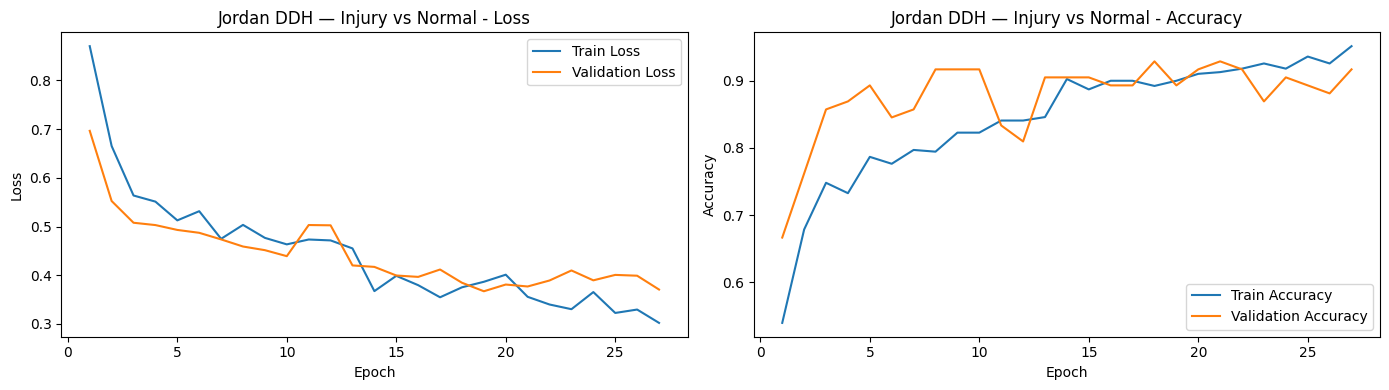

In [ ]:
plot_curves_clf(*jordan_history, title='Jordan DDH — Injury vs Normal')
# Plot training vs validation loss and accuracy curves
# This helps us check model performance and detect overfitting

## A-7. Evaluation (TTA)



Jordan DDH Classification — TTA (n_augments=5)
Accuracy: 88.10%

              precision    recall  f1-score   support

         ddh       0.70      0.78      0.74        18
      normal       0.88      0.83      0.86        36
    not_xray       1.00      1.00      1.00        30

    accuracy                           0.88        84
   macro avg       0.86      0.87      0.86        84
weighted avg       0.89      0.88      0.88        84



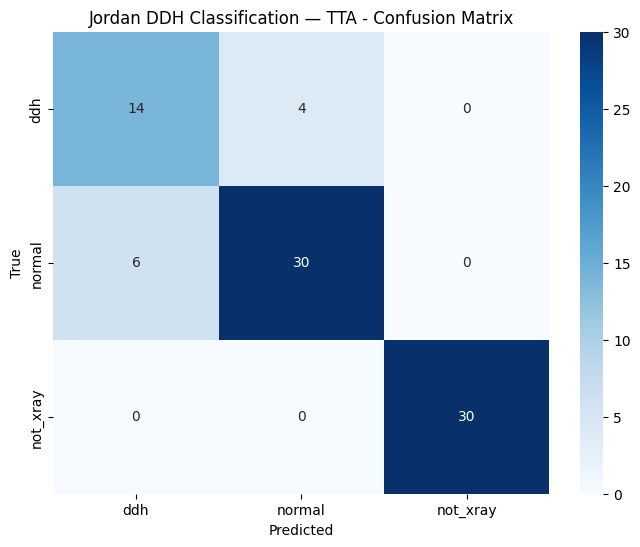

In [ ]:
# ── TTA evaluation (Test-Time Augmentation) ──
# Improves prediction stability by averaging multiple augmented versions of each image

def evaluate_with_tta(model, raw_test_subset, class_names,
                      n_augments=5, title='TTA Evaluation'):
    """
    Applies multiple augmentations per test image and averages predictions
    to get more stable and accurate results.
    """

    # Define augmentation pipeline for TTA
    tta_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Lambda(lambda img: img.convert('RGB')),
        ApplyCLAHE(clip_limit=2.0, tile_grid_size=(8, 8)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    model.eval()

    all_preds, all_labels_tta = [], []

    for idx in range(len(raw_test_subset)):
        img, label = raw_test_subset[idx]

        probs_sum = torch.zeros(len(class_names)).to(device)
        # Store summed probabilities from multiple augmentations

        with torch.no_grad():
            for _ in range(n_augments):
                aug_img = tta_transform(img).unsqueeze(0).to(device)
                # Apply random augmentation to same image

                out = model(aug_img)
                probs_sum += torch.softmax(out.squeeze(), dim=0)
                # Add predicted probabilities

        pred = probs_sum.argmax().item()
        # Final prediction is the average probability result

        all_preds.append(pred)
        all_labels_tta.append(label)

    all_preds = np.array(all_preds)
    all_labels_tta = np.array(all_labels_tta)

    accuracy = (all_preds == all_labels_tta).mean() * 100

    print("\n===================")
    print(f"{title} (n_augments={n_augments})")
    print("=====================")
    print(f"Accuracy: {accuracy:.2f}%")
    print("=====================\n")

    # Classification report (precision, recall, f1-score)
    print(classification_report(
        all_labels_tta,
        all_preds,
        target_names=class_names,
        zero_division=0
    ))

    # Confusion matrix visualization
    cm = confusion_matrix(all_labels_tta, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title(f'{title} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


# Run TTA evaluation on test set
evaluate_with_tta(
    jordan_model,
    raw_test_j,
    JORDAN_CLASSES,
    n_augments=5,
    title='Jordan DDH Classification — TTA'
)
# Evaluate model using Test-Time Augmentation for better stability

---
# MODULE B — MTDDH Keypoint Dataset Loading


## B-1. Paths  ← ⚠️ Update before running


In [ ]:
#  Dataset 1 paths
# These paths point to Dataset1 (Keypoint dataset)
# - Images for training and validation
# - JSON files contain keypoint annotations (COCO format)

DS1_TRAIN_IMG  = '/content/drive/MyDrive/Colab Notebooks/DDH_Model/MTDDH/Dataset1/Keypoints/Train'
DS1_VAL_IMG    = '/content/drive/MyDrive/Colab Notebooks/DDH_Model/MTDDH/Dataset1/Keypoints/Validation'
DS1_TRAIN_JSON = '/content/drive/MyDrive/Colab Notebooks/DDH_Model/MTDDH/Dataset1/Keypoints/Keypoints_Train.json'
DS1_VAL_JSON   = '/content/drive/MyDrive/Colab Notebooks/DDH_Model/MTDDH/Dataset1/Keypoints/Keypoints_Validation.json'


# Dataset 2 paths
# Dataset2 contains COCO-format annotations for DDH keypoints
# Images are stored in nested folders:

DS2_IMG_DIR    = '/content/drive/MyDrive/Colab Notebooks/DDH_Model/MTDDH/Dataset2/png'
DS2_TRAIN_JSON = '/content/drive/MyDrive/Colab Notebooks/DDH_Model/MTDDH/Dataset2/coco/ddh_keypoint_train.json'
DS2_VAL_JSON   = '/content/drive/MyDrive/Colab Notebooks/DDH_Model/MTDDH/Dataset2/coco/ddh_keypoint_val.json'
DS2_TEST_JSON  = '/content/drive/MyDrive/Colab Notebooks/DDH_Model/MTDDH/Dataset2/coco/ddh_keypoint_test.json'


# Confirmation message
print('✅ Dataset paths are set successfully.')

## B-2. Debug JSON


In [ ]:
# Dataset Debugging
# This section checks:
# 1. JSON structure (images, annotations, keypoints)
# 2. Image file availability on disk
# 3. Missing or corrupted samples
# 4. Keypoint format consistency
#
# ds2=False → Dataset1 (simple COCO keypoints format)
# ds2=True  → Dataset2 (complex DDH format with merged annotations)

debug_json(DS1_TRAIN_JSON, DS1_TRAIN_IMG, ds2=False)   # Check Dataset1 training set
debug_json(DS1_VAL_JSON,   DS1_VAL_IMG,   ds2=False)   # Check Dataset1 validation set

debug_json(DS2_TRAIN_JSON, DS2_IMG_DIR,   ds2=True)    # Check Dataset2 training set
debug_json(DS2_VAL_JSON,   DS2_IMG_DIR,   ds2=True)    # Check Dataset2 validation set
debug_json(DS2_TEST_JSON,  DS2_IMG_DIR,   ds2=True)    # Check Dataset2 test set


  Keypoints_Train.json
  Keys       : ['images', 'categories', 'annotations']
  Images     :    780
  Annotations:    780
  KP order   : ['re', 'ry', 'rc', 'rh', 'le', 'ly', 'lc', 'lh']
  Found imgs :    780
  Missing    :      0 ✅
  Sample annotations:
    img_id=2164 (1675×1001) keypoints=8
    img_id=2165 (1020×705) keypoints=8
    img_id=2166 (1360×952) keypoints=8

  Keypoints_Validation.json
  Keys       : ['images', 'categories', 'annotations']
  Images     :    208
  Annotations:    208
  KP order   : ['re', 'ry', 'rc', 'rh', 'le', 'ly', 'lc', 'lh']
  Found imgs :    208
  Missing    :      0 ✅
  Sample annotations:
    img_id=1889 (998×831) keypoints=8
    img_id=1890 (1076×733) keypoints=8
    img_id=1891 (864×698) keypoints=8

  ddh_keypoint_train.json
  Keys       : ['info', 'licenses', 'images', 'categories', 'annotations']
  Images     :    731
  Annotations:   8701
  KP order   : ['A', 'B', 'C', 'H']
  Cat-6 KP   :   1462
  Found imgs :    731
  Missing    :      0 ✅
  

## B-3. Build & Load Datasets


In [ ]:
# Load Dataset 1
# Dataset1 is used for keypoint detection training/validation
# It uses DS1Dataset class with augmentation for training

print('Loading Dataset 1 ...')

ds1_tr = DS1Dataset(
    DS1_TRAIN_JSON,
    DS1_TRAIN_IMG,
    train_tfm,
    augment_hflip=True   # enable horizontal flip augmentation
)

ds1_vl = DS1Dataset(
    DS1_VAL_JSON,
    DS1_VAL_IMG,
    val_tfm              # no augmentation for validation
)


# Load Dataset 2
# Dataset2 contains DDH COCO-format annotations
# Used for additional training + evaluation

print('Loading Dataset 2 ...')

ds2_tr = DS2Dataset(
    DS2_TRAIN_JSON,
    DS2_IMG_DIR,
    train_tfm,
    augment_hflip=True
)

ds2_vl = DS2Dataset(
    DS2_VAL_JSON,
    DS2_IMG_DIR,
    val_tfm
)

ds2_te = DS2Dataset(
    DS2_TEST_JSON,
    DS2_IMG_DIR,
    val_tfm
)


# Combine datasets
# We merge Dataset1 + Dataset2 for better generalization

train_ds = ConcatDataset([ds1_tr, ds2_tr])
val_ds   = ConcatDataset([ds1_vl, ds2_vl])
test_ds  = ds2_te


# Dataset summary
print(f'\nTrain samples: {len(train_ds)} | Val samples: {len(val_ds)} | Test samples: {len(test_ds)}')

# Safety check: ensure dataset is not empty
if len(train_ds) == 0:
    print('❌ No samples found — check debug_json() and dataset paths.')
else:
    print('✅ Datasets loaded successfully.')

## B-4. DataLoaders


In [ ]:
#  DataLoaders
# DataLoader is responsible for:
# - Splitting dataset into batches
# - Shuffling training data (for better generalization)
# - Efficient loading using multiple workers

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,        # shuffle only for training
    num_workers=0,
    pin_memory=True      # speeds up GPU transfer
)

val_loader = DataLoader(
    val_ds,
    batch_size=8,
    shuffle=False,       # no shuffle in validation
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


# Dataset Summary
print(
    f'Train batches: {len(train_loader)} | '
    f'Val batches: {len(val_loader)} | '
    f'Test batches: {len(test_loader)}'
)

## B-5. Visualise GT Keypoints


In [ ]:
def show_gt(img_t, kps_n, vis_m, title='', ax=None):
    """
    Visualize ground-truth keypoints on an image.

    Args:
        img_t  : image tensor (C,H,W)
        kps_n  : normalized keypoints [0,1]
        vis_m  : visibility mask (1=visible, 0=hidden)
        title  : plot title
        ax     : matplotlib axis (optional)
    """

    # Convert tensor image back to displayable format
    img = to_display(img_t)
    H, W = img.shape[:2]

    # Create axis if not provided
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(5, 5))

    ax.imshow(img)

    # Plot all visible keypoints
    for k in range(NUM_KP):
        if vis_m[k] > 0:
            x, y = kps_n[k, 0] * W, kps_n[k, 1] * H

            # Draw keypoint
            ax.scatter(
                x, y,
                c=KEYPOINT_COLORS[k],
                s=70,
                zorder=5,
                edgecolors='white',
                linewidths=0.6
            )

            # Add keypoint name label
            ax.annotate(
                KEYPOINT_NAMES[k],
                (x, y),
                xytext=(3, 3),
                textcoords="offset points",
                fontsize=6,
                color=KEYPOINT_COLORS[k]
            )

    ax.set_title(title)
    ax.axis('off')


# Visual check on training batch

# This step is important to verify:
# - keypoints alignment is correct
# - augmentation did not break labels
# - normalization is correct

imgs, hms, kps, vis = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(min(8, len(imgs))):
    show_gt(
        imgs[i],
        kps[i].numpy(),
        vis[i].numpy(),
        f'Train {i+1}',
        axes[i]
    )

plt.suptitle(
    'Ground Truth Keypoints — Visual Validation Check',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## B-6. Build


In [ ]:
#  Keypoint Model Setup

# This section initializes:
# 1. Keypoint detection model (DenseNet encoder + decoder)
# 2. Loss function (heatmap + coordinate regularization)
# 3. Optimizer with different learning rates for different parts

kp_net = DDHKeypointNet().to(device)  # Move model to GPU/CPU


#  Loss Function

# Combines:
# - Heatmap loss (pixel-wise supervision)
# - Coordinate loss (soft-argmax refinement)
kp_loss = MaskedHeatmapLoss(coord_weight=0.5)


#  Optimizer

# Different learning rates:
# - Encoder (pretrained DenseNet) → very small LR (fine-tuning)
# - Decoder → higher LR (learns keypoint prediction)
kp_optim = torch.optim.AdamW([
    {'params': kp_net.enc.denseblock4.parameters(), 'lr': 5e-5},
    {'params': kp_net.enc.norm5.parameters(),       'lr': 5e-5},
    {'params': kp_net.dec.parameters(),             'lr': 2e-4}
], weight_decay=1e-3)


#  Model Summary

print('✅ Keypoint model ready.')

# Count trainable parameters only
print( f'   Trainable params: {sum(p.numel() for p in kp_net.parameters() if p.requires_grad):,}')

## B-7. Train


In [ ]:
history = train_model(
    kp_net,          # keypoint model
    train_loader,    # training data
    val_loader,      # validation data
    kp_loss,         # loss function
    kp_optim,        # optimizer
    epochs=30,       # number of training epochs
    label='MTDDH',   # experiment name
    save='kp_best.pth',  # best model checkpoint
    vis_every=5      # visualize predictions every 5 epochs
)

## B-8. Plot Curves


In [ ]:
# This function visualizes the training progress of the keypoint model:
# - Loss (how well model fits heatmaps)
# - PCK (keypoint accuracy within threshold)
# - OKS (object keypoint similarity metric)

plot_curves( *history,title='MTDDH DDH Keypoint Detection')

# B-9.Keypoint Test Set Evaluation


In [ ]:
#  Load Best Trained Model
# Load the saved best model weights after training
kp_net.load_state_dict(torch.load('kp_best.pth', map_location=device))
kp_net.eval()  # set model to evaluation mode (no dropout / no batchnorm updates)


#  Initialize Metrics
tl = tp = to = 0.0   # total loss, PCK, OKS
all_pred = []        # store all predicted keypoints
all_gt   = []        # store all ground truth keypoints
all_vis  = []        # store visibility masks


# Testing Loop
# No gradients needed during evaluation → saves memory and computation
with torch.no_grad():
    for imgs, gt_hm, kps_gt, vis in test_loader:

        # Move data to GPU/CPU
        imgs, gt_hm, kps_gt, vis = (
            imgs.to(device),
            gt_hm.to(device),
            kps_gt.to(device),
            vis.to(device)
        )

        # Forward pass through model
        ph = kp_net(imgs)

        # Convert heatmaps → keypoint coordinates
        pc = soft_argmax(ph)

        # Compute metrics
        tl += kp_loss(ph, gt_hm, vis, pc, kps_gt).item()
        tp += pck(pc, kps_gt, vis)
        to += oks(pc, kps_gt, vis)

        # Save predictions for later analysis/visualization
        all_pred.append(pc.cpu())
        all_gt.append(kps_gt.cpu())
        all_vis.append(vis.cpu())


# Final Evaluation Summary
n = len(test_loader)

print(f'\n{"="*50}')
print('  TEST RESULTS')
print(f'{"="*50}')
print(f'  Loss    : {tl/n:.4f}')     # average heatmap loss
print(f'  PCK@0.05: {tp/n:.4f}')     # keypoint accuracy
print(f'  OKS     : {to/n:.4f}')     # keypoint similarity metric
print(f'{"="*50}')

## B-10. Per-Keypoint Error


In [ ]:
# Combine predictions, ground truth, and visibility masks from all test batches
P = torch.cat(all_pred)   # Predicted keypoints (B, K, 2)
G = torch.cat(all_gt)     # Ground truth keypoints (B, K, 2)
V = torch.cat(all_vis)    # Visibility mask (B, K)

# Compute Euclidean distance between predicted and true keypoints
dist = torch.norm(P - G, dim=-1)

# Lists to store mean and standard deviation error per keypoint
md_ = []  # mean distance per keypoint
sd_ = []  # std deviation per keypoint

# Loop over each keypoint
for k in range(NUM_KP):

    # Only consider visible keypoints
    vk = V[:, k].bool()

    if vk.sum() > 0:
        # Extract distances for visible samples only
        d = dist[vk, k]

        # Mean and std error for this keypoint
        md_.append(d.mean().item())
        sd_.append(d.std().item())
    else:
        # If no visible samples, set zero
        md_.append(0.)
        sd_.append(0.)

# Plot per-keypoint error distribution
fig, ax = plt.subplots(figsize=(12, 4))

# Bar plot with error bars (std deviation)
bars = ax.bar(
    KEYPOINT_NAMES,
    md_,
    yerr=sd_,
    color=KEYPOINT_COLORS,
    edgecolor='black',
    capsize=5
)

# Add numeric values above each bar
for bar, v in zip(bars, md_):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{v:.3f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_ylabel('Normalized Distance')  # Error metric
ax.set_title('Per-Keypoint Error — Test Set')  # Chart title

plt.tight_layout()
plt.show()


# MODULE C — Full Diagnosis Pipeline (Classification + Keypoints + Medical Guidance)



# when use Colab

In [ ]:
from google.colab import files

# Allowed image file extensions
allowed_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

# Upload file from local device
uploaded = files.upload()

# Check if user actually uploaded something
if not uploaded:
    raise ValueError('No image selected. Please upload an image.')

# Filter uploaded files to keep only valid image formats
valid_files = [f for f in uploaded.keys() if f.lower().endswith(allowed_ext)]

# If no valid image was found, raise an error
if not valid_files:
    raise ValueError('Please upload a valid image file.')

# Take the first valid image file
IMAGE_PATH = valid_files[0]

# Print selected image name
print(f'Selected: {IMAGE_PATH}')

# when use Visual Studio code

In [ ]:
# import tkinter as tk
# from tkinter import filedialog

# Create main tkinter window
# root = tk.Tk()

# Keep window always on top
# root.attributes('-topmost', True)

# Hide the main window (we only use file dialog)
# root.withdraw()

# Open file dialog to select an image file
# IMAGE_PATH = filedialog.askopenfilename(
#     title='Select X-Ray Image',
#     filetypes=[('Image Files', '*.jpg *.jpeg *.png *.bmp *.tiff')]
# )

# Close tkinter window
# root.destroy()

# Check if user selected a file
# if not IMAGE_PATH:
#     raise ValueError('No image selected. Please run again and select an image.')

# Print selected image path
# print(f'Selected: {IMAGE_PATH}')


In [ ]:
def full_diagnosis_pipeline(image_path):
    """
    Complete DDH diagnosis pipeline:
    1. Load and display input image
    2. Classify image (Not X-ray / Normal / DDH)
    3. If Not X-ray → show warning only
    4. If Normal → show keypoints + confidence only
    5. If DDH → run keypoint detection + severity + medical guidance
    """

    print('\n' + '=' * 55)
    print('  DDH COMPLETE DIAGNOSIS SYSTEM')
    print('=' * 55)

    # 1. Load image
    image_pil = Image.open(image_path).convert('RGB')

    # 2. Classification stage
    print('\nStage 1 — Classification')

    # Preprocess image for classifier
    input_tensor = clf_val_transforms(image_pil).unsqueeze(0).to(device)

    jordan_model.eval()
    with torch.no_grad():
        outputs = jordan_model(input_tensor)
        probs   = torch.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)

    # Get predicted class and confidence
    predicted_class = JORDAN_CLASSES[pred.item()]
    confidence      = conf.item()

    # Normalize class label
    cls_lower = predicted_class.lower()

    # Robust class detection: avoid false positive for 'xray' substring
    if cls_lower.startswith('not') or cls_lower in ('not_xray', 'not x-ray', 'not_x-ray'):
        final_class = 'Not X-ray'
    elif 'normal' in cls_lower:
        final_class = 'Normal'
    else:
        final_class = predicted_class

    # Flags for decision logic
    is_not_xray = (final_class == 'Not X-ray')
    is_normal   = (final_class.lower() == 'normal')
    is_ddh      = not is_not_xray and not is_normal

    print(f'  Predicted  : {final_class}  ({confidence:.4f})')

    # CASE A: NOT X-RAY
    if is_not_xray:
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        fig.patch.set_facecolor('#0d1117')

        ax.imshow(image_pil)
        ax.axis('off')

        ax.set_title(
            f'Not X-ray  |  Confidence: {confidence:.2%}',
            color='#e74c3c', fontsize=13, fontweight='bold'
        )

        ax.text(
            0.5, -0.06,
            '⚠ This image is not suitable for DDH diagnosis.\n'
            'Please upload a valid pelvic X-ray image.',
            transform=ax.transAxes,
            ha='center',
            fontsize=10,
            color='#f1c40f'
        )

        plt.show()
        return {
            'image': image_path,
            'final_class': final_class,
            'confidence': round(confidence, 4)
        }

    # CASE B & C: NORMAL or DDH → Keypoint model
    print('\nStage 2 — Keypoint Detection')

    kp_input_tensor = kp_val_tfm(image_pil).unsqueeze(0).to(device)

    kp_net.eval()
    with torch.no_grad():
        pred_hm     = kp_net(kp_input_tensor)
        pred_coords = soft_argmax(pred_hm)

    kps = pred_coords.squeeze(0).cpu().numpy()

    # Extract anatomical keypoints
    rtcc, ltcc = kps[0], kps[1]
    rasm, lasm = kps[2], kps[3]
    rfhc, lfhc = kps[4], kps[5]

    # Compute clinical measurements
    ai_r   = acetabular_index(rtcc, rasm)
    ai_l   = acetabular_index(ltcc, lasm)
    disp_r = lateral_displacement(rtcc, rfhc)
    disp_l = lateral_displacement(ltcc, lfhc)
    asym   = asymmetry_score(kps)

    # Get severity grade
    _, kp_severity, kp_side = grade(ai_r, ai_l)

    # Convert image for visualization
    img_np = to_display(kp_input_tensor.squeeze())
    H, W   = img_np.shape[:2]

    # Visualization colors
    sev_palette  = {'Normal': '#2ecc71', 'Mild': '#f1c40f',
                    'Moderate': '#e67e22', 'Severe': '#e74c3c'}

    diag_palette = {'Normal': '#2ecc71',
                    'Unilateral DDH': '#e67e22',
                    'Bilateral DDH': '#e74c3c'}

    note_map = {
        'Normal'  : 'No DDH signs detected.',
        'Mild'    : 'Mild DDH — monitoring required.',
        'Moderate': 'Moderate DDH — consult specialist.',
        'Severe'  : 'Severe DDH — urgent referral needed.'
    }

    # Adjust display for Normal cases
    if is_normal:
        severity_display = '---'
        severity_color   = '#aaaaaa'
        diag_color       = '#2ecc71'
    else:
        severity_display = kp_severity
        severity_color   = sev_palette.get(kp_severity, '#ffffff')
        diag_color       = diag_palette.get(final_class, '#e67e22')

    # Figure layout (3 panels)
    fig = plt.figure(figsize=(20, 8))
    gs = gridspec.GridSpec(1, 3)

    # Panel 1: Input image
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(image_pil)
    ax1.set_title(f'{final_class} ({confidence:.2%})')
    ax1.axis('off')

    # Panel 2: Keypoints overlay
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(img_np)

    for k, (x, y) in enumerate(kps):
        ax2.scatter(x * W, y * H, c=KEYPOINT_COLORS[k])

    ax2.set_title('Keypoints')
    ax2.axis('off')

    # Panel 3: Report summary
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.axis('off')

    ax3.text(0.5, 0.9, 'DDH REPORT', ha='center')

    ax3.text(0.5, 0.7, f'Class: {final_class}', ha='center')
    ax3.text(0.5, 0.6, f'Severity: {severity_display}', ha='center')
    ax3.text(0.5, 0.5, f'Confidence: {confidence:.2%}', ha='center')

    plt.tight_layout()
    plt.show()

    # Print summary
    print('\nFINAL REPORT')
    print('Class:', final_class)
    print('Confidence:', confidence)
    print('Severity:', severity_display)

    # Medical guidance (only for DDH or Normal)
    guidance_severity = kp_severity if is_ddh else 'Normal'

    show_medical_guidance(
        severity=guidance_severity,
        side=kp_side if is_ddh else '---',
        ai_r=ai_r,
        ai_l=ai_l,
        diagnosis=final_class,
        confidence=confidence
    )

    return {
        'image': image_path,
        'final_class': final_class,
        'confidence': round(confidence, 4),
        'severity': severity_display,
        'side': kp_side if is_ddh else '---',
        'ai_right': round(ai_r, 2),
        'ai_left': round(ai_l, 2),
        'asymmetry': round(asym, 4),
    }

**Run the complete DDH diagnosis pipeline on the selected image**

**This will:**

 **1. Classify the image (Normal / DDH / Not X-ray)**

**2. If valid X-ray → detect anatomical keypoints**

**3. Compute clinical measurements (AI angles, displacement, asymmetry)**

 **4. Determine severity level and affected side**

**5. Display visual results + medical report**

 **6. Return all results in a dictionary**

In [ ]:
result = full_diagnosis_pipeline(IMAGE_PATH)   # Run the complete DDH diagnosis pipeline on the selected image